In [22]:
from rdkit import Chem
from kartograf import SmallMoleculeComponent
from gufe import SmallMoleculeComponent
# kartograf
from kartograf.atom_mapper import KartografAtomMapper
from kartograf.atom_mapping_scorer import MappingRMSDScorer
from kartograf.atom_aligner import align_mol_shape
# lomap
from lomap import LomapAtomMapper
from lomap.gufe_bindings.scorers import default_lomap_score

In [23]:
sdfs = [f"mir.sdf", f"bi1.sdf"]
rdmols = [Chem.MolFromMolFile(sdf, removeHs=False) for sdf in sdfs]
rdmols = [Chem.AddHs(m, addCoords=False) for m in rdmols]

# Build Small Molecule Components
molA, molB = [SmallMoleculeComponent.from_rdkit(m) for m in rdmols]
#a_molB = align_mol_shape(molB, ref_mol=molA)
a_molB = molB


# Kartograf

In [59]:
from rdkit import Chem
from rdkit.Geometry import Point3D
from rdkit.Chem import rdMolAlign, AllChem

def filter_exclude_hydroge_atoms(
    molA: Chem.Mol, molB: Chem.Mol, mapping: dict[int, int]
) -> dict[int, int]:
    """Force a mapping to exclde H atoms"""
    filtered_mapping = {}
    for i, j in mapping.items():
        if molA.GetAtomWithIdx(i).GetAtomicNum() == 1 or molB.GetAtomWithIdx(j).GetAtomicNum() == 1:
            continue
        filtered_mapping[i] = j
    return filtered_mapping


def filter_element_changes(
    molA: Chem.Mol, molB: Chem.Mol, mapping: dict[int, int]
) -> dict[int, int]:
    """Forces a mapping to exclude any alchemical element changes in the core"""
    filtered_mapping = {}

    for i, j in mapping.items():
        if (
            molA.GetAtomWithIdx(i).GetAtomicNum()
            != molB.GetAtomWithIdx(j).GetAtomicNum()
        ):
            continue
        filtered_mapping[i] = j

    return filtered_mapping


def filter_mismatched_attached_h_count(
    molA: Chem.Mol, molB: Chem.Mol, mapping: dict[int, int]
) -> dict[int, int]:
    """
    Exclude mapped heavy-atom pairs where the number of directly attached H differs.
    This helps avoid HMR mass mismatches for 'common/core' atoms.
    """
    filtered = {}
    for i, j in mapping.items():
        a = molA.GetAtomWithIdx(i)
        b = molB.GetAtomWithIdx(j)

        hA = a.GetTotalNumHs(includeNeighbors=True)
        hB = b.GetTotalNumHs(includeNeighbors=True)

        if hA != hB:
            continue

        filtered[i] = j
    return filtered


additional_mapping_filter_functions = [filter_element_changes]
# if set hmr, don't include atom with different number of H attached
#additional_mapping_filter_functions.append(filter_mismatched_attached_h_count)

In [30]:
mapper = KartografAtomMapper(atom_max_distance=0.95, map_hydrogens_on_hydrogens_only=True, atom_map_hydrogens=False,
                            map_exact_ring_matches_only=False, allow_partial_fused_rings=True, allow_bond_breaks=False,
                            additional_mapping_filter_functions=additional_mapping_filter_functions
)

In [31]:
kartograf_mapping = next(mapper.suggest_mappings(molA, a_molB))
print(f"mapping: {kartograf_mapping.componentA_to_componentB}")

mapping: {9: 26, 10: 13, 11: 25, 12: 22, 13: 24, 14: 23, 15: 20, 16: 10, 17: 11, 24: 15, 26: 5}


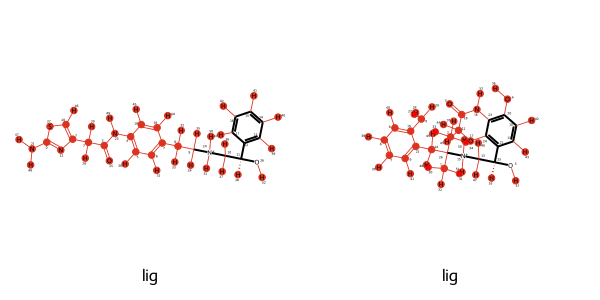

In [32]:
kartograf_mapping

# Lomap

In [54]:
lomap_mapper = LomapAtomMapper(
    time=20,
    threed=True,
    max3d=2.0,
    element_change=False,
    shift=True,
)

In [ ]:
lomap_mapping = next(lomap_mapper.suggest_mappings(molA, molB))
print(lomap_mapping.componentA_to_componentB)

{4: 6, 5: 8, 6: 19, 7: 21, 8: 14, 9: 26, 10: 13, 11: 25, 12: 22, 13: 24, 14: 23, 15: 20, 16: 10, 17: 11, 18: 9, 19: 7, 24: 15, 26: 5, 30: 40, 32: 49, 33: 48, 36: 47, 37: 46, 38: 53, 42: 42, 43: 43, 44: 41, 45: 39, 50: 50, 51: 51, 52: 37}


In [62]:
filter_exclude_hydroge_atoms(molA.to_rdkit(), molB.to_rdkit(), lomap_mapping.componentA_to_componentB)

{4: 6,
 5: 8,
 6: 19,
 7: 21,
 8: 14,
 9: 26,
 10: 13,
 11: 25,
 12: 22,
 13: 24,
 14: 23,
 15: 20,
 16: 10,
 17: 11,
 18: 9,
 19: 7,
 24: 15,
 26: 5}

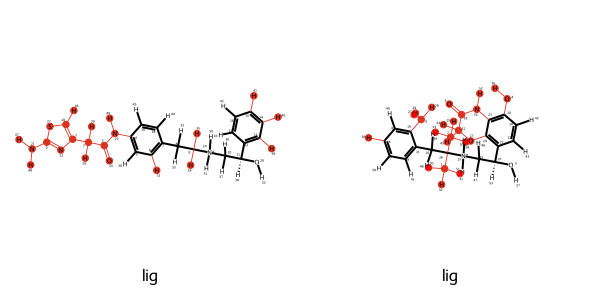

In [57]:
lomap_mapping

In [63]:
lomap_mapping.draw_to_file("mapping.png")